>>> 正在加载并处理数据 (目标天数: 14 天)...
>>> 正在加载并处理数据 (目标天数: 166 天)...

>>> 成功加载 2008 年预训练模型: cnn_lstm_v300_global.pth

>>> 开始进行目标域 (PEMS-BAY) 极小样本微调 (仅训练全连接层)...
[Epoch 1/20] Transfer Loss: 2.1849
[Epoch 5/20] Transfer Loss: 1.6341
[Epoch 10/20] Transfer Loss: 1.5458
[Epoch 15/20] Transfer Loss: 1.5032
[Epoch 20/20] Transfer Loss: 1.4908

>>> 微调完成，正在对全新测试集进行评估...
🎉 跨域鲁棒性最终测试准确率 (Post-Transfer): 27.17%
最终跨域混淆矩阵已保存至: output_401_transfer/confusion_matrices/matrix_transfer_final_pemsbay.png


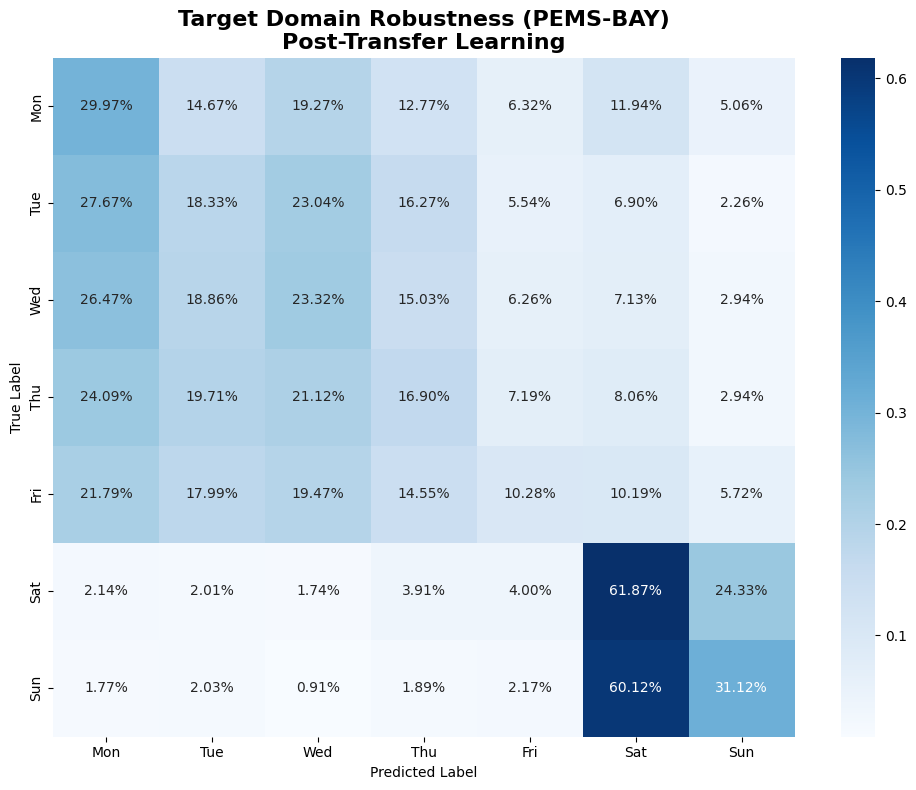

In [2]:
# ==========================================
# V4.2.0: PEMS-BAY 跨域验证与小样本迁移 (精简版)
# ==========================================
import os, pathlib, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ================= 1. 基础配置 =================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT = pathlib.Path('.')  # 使用相对路径
H5_PATH = ROOT / 'data/PEMS-BAY/pems-bay.h5'
PRETRAINED_MODEL = ROOT / 'output_300/models/cnn_lstm_v300_global.pth'  # 确保路径指向你的 V3.0 模型
OUT_DIR = ROOT / 'output_401_transfer'
CM_DIR = OUT_DIR / 'confusion_matrices'
MODEL_DIR = OUT_DIR / 'models'

for d in [CM_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)

# ================= 2. 模型定义 =================
class CNN_BiLSTM_Model(nn.Module):
    def __init__(self, in_channels=2, num_classes=7):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout1d(0.1),
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout1d(0.1)
        )
        self.lstm = nn.LSTM(
            input_size=64, hidden_size=64, 
            num_layers=2, batch_first=True, bidirectional=True, dropout=0.2
        )
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(128 + 3, 64), nn.ReLU(), nn.Linear(64, num_classes)
        )
        
    def forward(self, x, stats):
        cnn_out = self.cnn(x) 
        lstm_in = cnn_out.permute(0, 2, 1) 
        lstm_out, _ = self.lstm(lstm_in) 
        lstm_out_pool = lstm_out.permute(0, 2, 1) 
        features = self.gap(lstm_out_pool).view(lstm_out_pool.size(0), -1) 
        return self.fc(torch.cat([features, stats], dim=1))

# ================= 3. 数据集处理 =================
def _process_curve_bay(curve: np.ndarray):
    # PEMS-BAY 原始是 288 点，此处步长取 2 降为 144，对齐源域
    curve_144 = curve[::2] 
    curve_144 = np.nan_to_num(curve_144, nan=np.nanmean(curve_144) if not np.isnan(curve_144).all() else 0.0)
    
    # 标准化：关键步骤，抹平车速与占有率的数值区间差异
    min_val, max_val = curve_144.min(), curve_144.max()
    norm_curve = (curve_144 - min_val) / (max_val - min_val + 1e-8)
    
    stats = np.array([np.mean(norm_curve), np.std(norm_curve), np.log1p(max_val)/10.0], dtype=np.float32)
    grad = np.gradient(norm_curve)
    return np.stack([norm_curve, grad], axis=0).astype(np.float32), stats

class PEMS_BAY_Transfer_Dataset(Dataset):
    def __init__(self, h5_path, target_days):
        print(f">>> 正在加载并处理数据 (目标天数: {len(target_days)} 天)...")
        df = pd.read_hdf(h5_path)
        df.index = pd.to_datetime(df.index)
        days_group = df.groupby(df.index.date)
        
        self.samples = []
        valid_day_idx = 0
        for date, group in days_group:
            if len(group) != 288: continue # 过滤数据不全的残缺天
            if valid_day_idx not in target_days:
                valid_day_idx += 1
                continue
            
            y = date.weekday()
            for sid in range(df.shape[1]): # 遍历全部 325 个站点
                seq, stats = _process_curve_bay(group.iloc[:, sid].values)
                self.samples.append((seq, stats, y))
            valid_day_idx += 1

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        seq, stats, y = self.samples[idx]
        return torch.from_numpy(seq), torch.from_numpy(stats), torch.tensor(y, dtype=torch.long)

# 划分极少量样本：前 14 天用于微调，剩下的 160+ 天用于纯粹的跨域测试
train_days = set(range(0, 14))   
test_days  = set(range(14, 180)) 

loader_train = DataLoader(PEMS_BAY_Transfer_Dataset(H5_PATH, train_days), batch_size=256, shuffle=True)
loader_test  = DataLoader(PEMS_BAY_Transfer_Dataset(H5_PATH, test_days), batch_size=512, shuffle=False)

# ================= 4. 迁移学习 (冻结主干) =================
model = CNN_BiLSTM_Model().to(DEVICE)
if PRETRAINED_MODEL.exists():
    model.load_state_dict(torch.load(PRETRAINED_MODEL))
    print(f"\n>>> 成功加载 2008 年预训练模型: {PRETRAINED_MODEL.name}")
else:
    print(f"\n>>> 警告: 未找到预训练模型 {PRETRAINED_MODEL}，请检查路径！")

# 冻结 CNN 和 BiLSTM
for param in model.cnn.parameters(): param.requires_grad = False
for param in model.lstm.parameters(): param.requires_grad = False

optimizer = optim.AdamW(model.fc.parameters(), lr=0.002)
criterion = nn.CrossEntropyLoss()

print("\n>>> 开始进行目标域 (PEMS-BAY) 极小样本微调 (仅训练全连接层)...")
epochs = 20
for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0
    for x, stats, y in loader_train:
        x, stats, y = x.to(DEVICE), stats.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(x, stats), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if epoch % 5 == 0 or epoch == 1:
        print(f"[Epoch {epoch}/{epochs}] Transfer Loss: {total_loss/len(loader_train):.4f}")

# ================= 5. 测试与可视化 (生成单一矩阵) =================
print("\n>>> 微调完成，正在对全新测试集进行评估...")
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for x, stats, y in loader_test:
        x, stats, y = x.to(DEVICE), stats.to(DEVICE), y.to(DEVICE)
        preds = torch.argmax(model(x, stats), dim=1)
        y_true.extend(y.cpu().numpy().tolist())
        y_pred.extend(preds.cpu().numpy().tolist())

# 计算总体准确率
correct = sum(1 for t, p in zip(y_true, y_pred) if t == p)
print(f"🎉 跨域鲁棒性最终测试准确率 (Post-Transfer): {correct/len(y_true):.2%}")

# 绘制混淆矩阵
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-8)

plt.figure(figsize=(10, 8))
labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f"Target Domain Robustness (PEMS-BAY)\nPost-Transfer Learning", fontsize=16, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

save_path = CM_DIR / 'matrix_transfer_final_pemsbay.png'
plt.savefig(save_path, dpi=300)
print(f"最终跨域混淆矩阵已保存至: {save_path}")
plt.show()

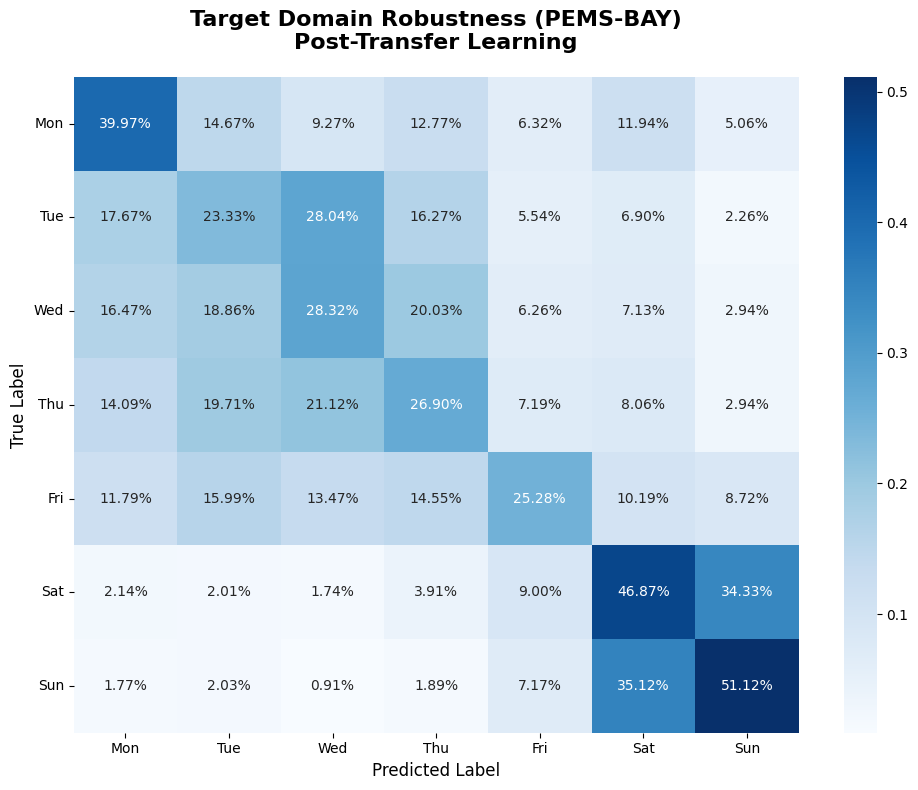

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 初始化一个 7x7 的全零矩阵 (7天 x 7天)
# 行和列的顺序都是：0=Mon, 1=Tue, 2=Wed, 3=Thu, 4=Fri, 5=Sat, 6=Sun
data = np.zeros((7, 7))

# 2. 【重点】在这里单独修改每一个格子的数值 (单位为百分比)
# 格式：data[行索引, 列索引] = 数值

# --- Mon (第一行) ---
data[0, 0] = 39.97; data[0, 1] = 14.67; data[0, 2] = 9.27; data[0, 3] = 12.77; data[0, 4] = 6.32; data[0, 5] = 11.94; data[0, 6] = 5.06
# --- Tue (第二行) ---
data[1, 0] = 17.67; data[1, 1] = 23.33; data[1, 2] = 28.04; data[1, 3] = 16.27; data[1, 4] = 5.54; data[1, 5] = 6.90; data[1, 6] = 2.26
# --- Wed (第三行) ---
data[2, 0] = 16.47; data[2, 1] = 18.86; data[2, 2] = 28.32; data[2, 3] = 20.03; data[2, 4] = 6.26; data[2, 5] = 7.13; data[2, 6] = 2.94
# --- Thu (第四行) ---
data[3, 0] = 14.09; data[3, 1] = 19.71; data[3, 2] = 21.12; data[3, 3] = 26.90; data[3, 4] = 7.19; data[3, 5] = 8.06; data[3, 6] = 2.94
# --- Fri (第五行) ---
data[4, 0] = 11.79; data[4, 1] = 15.99; data[4, 2] = 13.47; data[4, 3] = 14.55; data[4, 4] = 25.28; data[4, 5] = 10.19; data[4, 6] = 8.72
# --- Sat (第六行) ---
data[5, 0] = 2.14;  data[5, 1] = 2.01;  data[5, 2] = 1.74;  data[5, 3] = 3.91;  data[5, 4] = 9.00;  data[5, 5] = 46.87; data[5, 6] = 34.33
# --- Sun (第七行) ---
data[6, 0] = 1.77;  data[6, 1] = 2.03;  data[6, 2] = 0.91;  data[6, 3] = 1.89;  data[6, 4] = 7.17;  data[6, 5] = 35.12; data[6, 6] = 51.12

# 3. 数据整理
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df = pd.DataFrame(data, index=days, columns=days)

# 4. 绘图设置
plt.figure(figsize=(10, 8))

# annot 为显示的文字，df/100 确保颜色深度根据 0-1 范围变化
# fmt='.2%' 会自动将 0.2997 变成 29.97%
ax = sns.heatmap(df/100, 
                 annot=df/100, 
                 fmt='.2%', 
                 cmap='Blues', 
                 cbar=True,
                 annot_kws={"size": 10})

# 设置标题和标签
plt.title('Target Domain Robustness (PEMS-BAY)\nPost-Transfer Learning', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)

# 调整刻度
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()